# 🔬 Analyse Vidéo Distribuée avec Accélération GPU

**Application** : Vidéosurveillance intelligente  
**Technologies** : YOLOv8, OpenCV, multiprocessing (simulation MPI), GPU CUDA  
**Plateforme** : Kaggle (GPU T4 / P100, ~30 GB RAM)

---

## ✅ Corrections appliquées (vs version Colab qui plantait)

| Problème original | Correction appliquée |
|---|---|
| Toutes les frames chargées en RAM (~27 GB) | Chaque worker lit **sa portion directement** depuis le fichier |
| 4 workers × YOLOv8-Large (~870 MB chacun) | Modèle `yolov8n.pt` (6 MB) + 2 workers |
| IMG_SIZE = 1280 (très lourd) | IMG_SIZE = 640 (bon compromis) |
| Frames annotées doublées en mémoire | Sauvegarde **directement sur disque** par worker |

---

📋 **Architecture du système** :
- Chaque nœud lit et traite **sa portion du flux vidéo** (pas de copie en RAM)
- Traitement d'image accéléré sur GPU (mode séquentiel) ou CPU (mode distribué)
- Agrégation des résultats via `multiprocessing.Pool` (simulation MPI)


## 📋 Instructions Kaggle

1. **Activer le GPU** : Settings → Accelerator → **GPU T4 x2** (ou P100)
2. **Uploader votre vidéo** : + Add Data → Upload → choisir votre fichier `.mp4`  
   Le fichier sera disponible dans `/kaggle/input/<nom-dataset>/votre_video.mp4`
3. **Mettre à jour `VIDEO_PATH`** dans la Cellule 2 avec le bon chemin
4. Exécuter toutes les cellules dans l'ordre


## 📦 Cellule 1 — Installation des bibliothèques

In [13]:
import subprocess
import sys

print("⏳ Installation des bibliothèques...")

# Installation ciblée SANS mettre à jour les dépendances existantes
# --no-deps évite les conflits avec dask-cuda / cuml de Kaggle
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "ultralytics",
    "psutil",
    "--no-deps",      # ← Ne touche pas aux dépendances existantes
    "--quiet"
], check=True)

# Installer uniquement les dépendances manquantes d'ultralytics
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "torch", "torchvision", "opencv-python-headless",
    "Pillow", "PyYAML", "requests", "scipy", "tqdm",
    "--quiet"
], check=True)

print("✅ Bibliothèques installées sans conflits")

# Vérification
import cv2, torch, psutil
from ultralytics import YOLO
print(f"   torch     : {torch.__version__}")
print(f"   cuda dispo : {torch.cuda.is_available()}")
print(f"   opencv    : {cv2.__version__}")

⏳ Installation des bibliothèques...
✅ Bibliothèques installées sans conflits
   torch     : 2.10.0+cu128
   cuda dispo : True
   opencv    : 4.13.0


## ⚙️ Cellule 2 — Configuration globale

⚠️ **Modifiez `VIDEO_PATH`** avec le chemin de votre vidéo uploadée sur Kaggle.

In [14]:
import cv2
import time
import psutil
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════
# CONFIGURATION GLOBALE — ADAPTÉE KAGGLE
# ═══════════════════════════════════════════════════════

# ⚠️ MODIFIEZ CE CHEMIN avec votre vidéo uploadée
# Exemple : "/kaggle/input/mon-dataset/surveillance.mp4"
VIDEO_PATH = "/kaggle/input/datasets/zainabrhouni/vdtester/test.mp4"

# Paramètres optimisés pour Kaggle
N_WORKERS     = 2              # 2 workers (économise la RAM)
CONF_THRESHOLD = 0.3           # Seuil de confiance YOLO
IMG_SIZE      = 640            # ← Réduit de 1280 → 640 (4× moins de mémoire)
MODEL_NAME    = "yolov8l.pt"   # ← Nano (6 MB) au lieu de Large (870 MB)
OUTPUT_DIR    = "/kaggle/working"  # Dossier de sortie Kaggle
MAX_FRAMES    = 150             # Limite de frames pour les tests (mettre None pour tout traiter)

# ═══════════════════════════════════════════════════════
print("═" * 60)
print("⚙️  CONFIGURATION DU SYSTÈME DISTRIBUÉ (KAGGLE)")
print("═" * 60)
print(f"   📹 Vidéo source     : {VIDEO_PATH}")
print(f"   🔧 Workers (nœuds)  : {N_WORKERS}")
print(f"   🧠 Modèle YOLO      : {MODEL_NAME}")
print(f"   📊 Confiance        : {CONF_THRESHOLD}")
print(f"   📐 Résolution       : {IMG_SIZE}px")
print(f"   🎬 Max frames       : {MAX_FRAMES if MAX_FRAMES else 'Toutes'}")
print(f"   💾 Sortie           : {OUTPUT_DIR}")
print("═" * 60)

# Vérification de la vidéo
if not os.path.exists(VIDEO_PATH):
    print(f"\n❌ ERREUR : Vidéo non trouvée à {VIDEO_PATH}")
    print("   → Uploadez votre vidéo via + Add Data")
    print("   → Puis mettez à jour VIDEO_PATH ci-dessus")
else:
    print(f"\n✅ Vidéo trouvée : {VIDEO_PATH}")
    size_mb = os.path.getsize(VIDEO_PATH) / 1e6
    print(f"   Taille : {size_mb:.1f} MB")

════════════════════════════════════════════════════════════
⚙️  CONFIGURATION DU SYSTÈME DISTRIBUÉ (KAGGLE)
════════════════════════════════════════════════════════════
   📹 Vidéo source     : /kaggle/input/datasets/zainabrhouni/vdtester/test.mp4
   🔧 Workers (nœuds)  : 2
   🧠 Modèle YOLO      : yolov8l.pt
   📊 Confiance        : 0.3
   📐 Résolution       : 640px
   🎬 Max frames       : 150
   💾 Sortie           : /kaggle/working
════════════════════════════════════════════════════════════

✅ Vidéo trouvée : /kaggle/input/datasets/zainabrhouni/vdtester/test.mp4
   Taille : 37.7 MB


## ✂️ Cellule 3 — Analyse et découpage de la vidéo (Scatter)

**CORRECTION CLÉ** : On ne charge plus les frames en mémoire.
On ne calcule que les **index de début/fin** pour chaque worker.

🎯 **Concept MPI** : Simule `MPI_Scatter` — le master distribue la plage de frames à traiter.

In [15]:
def analyze_and_split_video(video_path, n_workers, max_frames=None):
    """
    Analyse la vidéo et calcule les plages de frames pour chaque worker.
    
    CORRECTION : On retourne des (start, end) indices — PAS les frames elles-mêmes.
    Chaque worker lira sa portion directement depuis le fichier vidéo.
    
    Args:
        video_path : chemin du fichier vidéo
        n_workers  : nombre de workers (nœuds MPI)
        max_frames : limite de frames à traiter (None = tout)
    
    Returns:
        total_frames, fps, width, height, chunks (liste de tuples (start, end))
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise FileNotFoundError(f"❌ Vidéo {video_path} introuvable")
    
    # Propriétés vidéo
    total_frames_real = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    
    # Limiter si demandé
    total_frames = min(total_frames_real, max_frames) if max_frames else total_frames_real
    
    # ═══════════════════════════════════════════════════
    # SCATTER LOGIQUE — indices seulement, pas de données
    # ═══════════════════════════════════════════════════
    chunk_size = total_frames // n_workers
    chunks = []
    
    for i in range(n_workers):
        start = i * chunk_size
        end   = total_frames if i == n_workers - 1 else (i + 1) * chunk_size
        chunks.append((start, end))
    
    # Estimation mémoire
    frame_size_mb = (width * height * 3) / 1e6
    old_ram_gb    = total_frames * frame_size_mb / 1000
    new_ram_gb    = chunk_size * frame_size_mb / 1000  # 1 chunk à la fois
    
    print("\n" + "═" * 60)
    print("📹 INFORMATIONS VIDÉO")
    print("═" * 60)
    print(f"   Frames totales      : {total_frames_real}")
    print(f"   Frames à traiter    : {total_frames}")
    print(f"   Résolution          : {width}×{height}")
    print(f"   FPS                 : {fps:.2f}")
    print(f"   Durée totale        : {total_frames_real/fps:.1f}s")
    
    print("\n" + "═" * 60)
    print("💾 ESTIMATION MÉMOIRE (CORRECTION APPLIQUÉE)")
    print("═" * 60)
    print(f"   ❌ Avant (tout en RAM) : ~{old_ram_gb:.1f} GB  ← plantait")
    print(f"   ✅ Après (streaming)   : ~{new_ram_gb:.2f} GB par worker")
    print(f"   🎯 Gain mémoire        : ×{old_ram_gb/max(new_ram_gb,0.01):.0f}")
    
    print("\n" + "═" * 60)
    print(f"✂️  DÉCOUPAGE MPI — {n_workers} WORKERS")
    print("═" * 60)
    for i, (s, e) in enumerate(chunks):
        print(f"   🖥️  Worker {i} : frames {s:4d} → {e-1:4d}  ({e-s} frames)")
    print("═" * 60)
    
    return total_frames, fps, width, height, chunks


total_frames, fps_video, width, height, chunks = analyze_and_split_video(
    VIDEO_PATH, N_WORKERS, MAX_FRAMES
)
print("\n✅ Découpage calculé (aucune frame chargée en RAM)")


════════════════════════════════════════════════════════════
📹 INFORMATIONS VIDÉO
════════════════════════════════════════════════════════════
   Frames totales      : 597
   Frames à traiter    : 150
   Résolution          : 2560×1440
   FPS                 : 25.00
   Durée totale        : 23.9s

════════════════════════════════════════════════════════════
💾 ESTIMATION MÉMOIRE (CORRECTION APPLIQUÉE)
════════════════════════════════════════════════════════════
   ❌ Avant (tout en RAM) : ~1.7 GB  ← plantait
   ✅ Après (streaming)   : ~0.83 GB par worker
   🎯 Gain mémoire        : ×2

════════════════════════════════════════════════════════════
✂️  DÉCOUPAGE MPI — 2 WORKERS
════════════════════════════════════════════════════════════
   🖥️  Worker 0 : frames    0 →   74  (75 frames)
   🖥️  Worker 1 : frames   75 →  149  (75 frames)
════════════════════════════════════════════════════════════

✅ Découpage calculé (aucune frame chargée en RAM)


## 🖥️ Cellule 4 — Fonction de traitement par worker

**CORRECTION CLÉ** : Chaque worker **ouvre lui-même le fichier vidéo** et lit sa portion.
Les frames annotées sont **sauvegardées directement sur disque** (pas accumulées en RAM).

🎯 **Concept MPI** : Chaque `rank` travaille sur ses données locales sans partage de mémoire.

In [16]:
from multiprocessing import Pool
from ultralytics import YOLO


def process_worker(args):
    """
    Fonction exécutée par chaque worker MPI.
    
    CORRECTIONS vs version originale :
    - Lit les frames directement depuis le fichier (streaming)
    - Ne stocke PAS les frames annotées en mémoire
    - Sauvegarde les frames annotées sur disque au fur et à mesure
    
    Args (tuple):
        worker_id   : identifiant du worker (rank MPI)
        start_frame : première frame à traiter
        end_frame   : dernière frame (exclue)
        device      : 'cpu' ou 'cuda'
        model_name  : nom du modèle YOLO
        conf        : seuil de confiance
        img_size    : résolution d'entrée
        video_path  : chemin vers la vidéo
        output_dir  : dossier de sortie des frames annotées
    
    Returns:
        (worker_id, n_frames, processing_times, cpu_usages, output_paths)
    """
    worker_id, start_frame, end_frame, device, model_name, conf, img_size, video_path, output_dir = args
    
    import cv2
    import time
    import psutil
    import warnings
    warnings.filterwarnings('ignore')
    from ultralytics import YOLO
    
    # Chargement du modèle (chaque worker a sa propre instance)
    model = YOLO(model_name)
    model.to(device)
    
    # Ouverture directe du fichier vidéo par ce worker
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)  # Seek vers la position de départ
    
    processing_times = []
    cpu_usages       = []
    output_paths     = []  # Chemins des frames sauvegardées
    process          = psutil.Process()
    n_frames         = end_frame - start_frame
    
    for idx in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        
        # Mesures
        cpu_before = process.cpu_percent(interval=None)
        t_start    = time.perf_counter()
        
        # ═══════════════════════════════════════════════
        # DÉTECTION YOLOv8
        # ═══════════════════════════════════════════════
        results        = model(frame, conf=conf, imgsz=img_size, verbose=False)
        annotated_frame = results[0].plot()
        
        t_end     = time.perf_counter()
        cpu_after = process.cpu_percent(interval=None)
        
        processing_times.append(t_end - t_start)
        cpu_usages.append((cpu_before + cpu_after) / 2)
        
        # CORRECTION : Sauvegarde sur disque immédiatement (ne pas accumuler en RAM)
        frame_filename = os.path.join(output_dir, f"worker{worker_id}_frame{start_frame + idx:06d}.jpg")
        cv2.imwrite(frame_filename, annotated_frame, [cv2.IMWRITE_JPEG_QUALITY, 85])
        output_paths.append(frame_filename)
        
        # Progression
        if (idx + 1) % 50 == 0 or idx == n_frames - 1:
            print(f"   [Worker {worker_id}] {idx+1}/{n_frames} frames traitées")
    
    cap.release()
    return worker_id, len(output_paths), processing_times, cpu_usages, output_paths


print("✅ Fonction worker définie")
print("   → Chaque worker ouvre le fichier vidéo lui-même (streaming)")
print("   → Les frames annotées sont sauvegardées sur disque immédiatement")
print("   → Aucune accumulation en RAM")

✅ Fonction worker définie
   → Chaque worker ouvre le fichier vidéo lui-même (streaming)
   → Les frames annotées sont sauvegardées sur disque immédiatement
   → Aucune accumulation en RAM


## 🧠 Cellule 5 — Traitement distribué sur CPU

Lancement de `N_WORKERS` processus en parallèle sur CPU.

**Étapes MPI simulées** :
1. **Scatter** : Distribution des plages de frames aux workers
2. **Compute** : Traitement parallèle (workers simultanés)
3. **Gather** : Réassemblage des chemins de fichiers dans l'ordre

In [18]:
def run_distributed(chunks, n_workers, model_name, conf, img_size,
                    video_path, output_dir, device='cpu'):
    
    mode = "CPU" if device == 'cpu' else "GPU"
    print("\n" + "═" * 60)
    print(f"{'🧠' if device=='cpu' else '🚀'} TRAITEMENT DISTRIBUÉ SUR {mode}")
    print("═" * 60)
    
    out_subdir = os.path.join(output_dir, f"frames_{device}")
    os.makedirs(out_subdir, exist_ok=True)
    
    worker_args = []
    for i, (start, end) in enumerate(chunks):
        worker_args.append((
            i, start, end, device, model_name, conf, 
            img_size, video_path, out_subdir
        ))
    
    print("📤 Distribution des chunks (MPI_Scatter)...")
    for i, (wid, s, e, dev, *_) in enumerate(worker_args):
        print(f"   Worker {wid} → frames {s}–{e-1} ({e-s} frames) sur {dev.upper()}")
    
    print(f"\n⚡ Traitement en cours (séquentiel — fiable sur Kaggle)...\n")
    start_time = time.time()
    
    # ✅ CORRECTION : séquentiel pour CPU ET GPU
    # Pool bloque silencieusement sur Kaggle avec yolov8l
    results = []
    for arg in worker_args:
        print(f"▶️  Démarrage Worker {arg[0]}...")
        result = process_worker(arg)
        results.append(result)
        print(f"✅ Worker {arg[0]} terminé — {result[1]} frames\n")
    
    end_time = time.time()
    
    # GATHER
    print("📦 Agrégation des résultats (MPI_Gather)...")
    results_sorted = sorted(results, key=lambda x: x[0])
    
    all_paths, all_times, all_cpu = [], [], []
    
    for worker_id, n_frames, times, cpus, paths in results_sorted:
        all_paths.extend(paths)
        all_times.extend(times)
        all_cpu.extend(cpus)
        print(f"   ✓ Worker {worker_id} : {n_frames} frames agrégées")
    
    total_time     = end_time - start_time
    fps_processing = len(all_paths) / total_time
    avg_cpu        = np.mean(all_cpu) if all_cpu else 0
    
    print("\n" + "═" * 60)
    print(f"✅ RÉSULTATS {mode} DISTRIBUÉ")
    print("═" * 60)
    print(f"   📊 Frames traitées     : {len(all_paths)}")
    print(f"   ⏱️  Temps total         : {total_time:.2f} secondes")
    print(f"   🚀 FPS traitement       : {fps_processing:.2f}")
    print(f"   ⏱️  Temps moyen/frame   : {np.mean(all_times):.3f}s")
    print(f"   📈 CPU moyen (hôte)    : {avg_cpu:.1f}%")
    print("═" * 60)
    
    return {
        'paths': all_paths,
        'times': all_times,
        'cpu': all_cpu,
        'total_time': total_time,
        'fps': fps_processing,
        'avg_cpu': avg_cpu,
        'worker_results': results_sorted
    }


# EXÉCUTION
cpu_results = run_distributed(
    chunks, N_WORKERS, MODEL_NAME, CONF_THRESHOLD, IMG_SIZE,
    VIDEO_PATH, OUTPUT_DIR, device='cpu'
)


════════════════════════════════════════════════════════════
🧠 TRAITEMENT DISTRIBUÉ SUR CPU
════════════════════════════════════════════════════════════
📤 Distribution des chunks (MPI_Scatter)...
   Worker 0 → frames 0–74 (75 frames) sur CPU
   Worker 1 → frames 75–149 (75 frames) sur CPU

⚡ Traitement en cours (séquentiel — fiable sur Kaggle)...

▶️  Démarrage Worker 0...
   [Worker 0] 50/75 frames traitées
   [Worker 0] 75/75 frames traitées
✅ Worker 0 terminé — 75 frames

▶️  Démarrage Worker 1...
   [Worker 1] 50/75 frames traitées
   [Worker 1] 75/75 frames traitées
✅ Worker 1 terminé — 75 frames

📦 Agrégation des résultats (MPI_Gather)...
   ✓ Worker 0 : 75 frames agrégées
   ✓ Worker 1 : 75 frames agrégées

════════════════════════════════════════════════════════════
✅ RÉSULTATS CPU DISTRIBUÉ
════════════════════════════════════════════════════════════
   📊 Frames traitées     : 150
   ⏱️  Temps total         : 93.75 secondes
   🚀 FPS traitement       : 1.60
   ⏱️  Temps moyen/

## 💾 Cellule 6 — Assemblage de la vidéo CPU annotée

Réassemblage des frames sauvegardées sur disque en vidéo finale.

In [19]:
def assemble_video_from_frames(frame_paths, output_path, fps, width, height):
    """
    Assemble des frames JPEG (sur disque) en un fichier vidéo.
    Utilise un buffer réduit pour économiser la RAM.
    """
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    print(f"💾 Assemblage de {len(frame_paths)} frames vers {output_path}...")
    
    for i, path in enumerate(sorted(frame_paths)):
        frame = cv2.imread(path)
        if frame is not None:
            # Redimensionner si nécessaire (YOLO peut changer la taille)
            if frame.shape[1] != width or frame.shape[0] != height:
                frame = cv2.resize(frame, (width, height))
            out.write(frame)
        
        if (i + 1) % 100 == 0:
            print(f"   {i+1}/{len(frame_paths)} frames assemblées")
    
    out.release()
    size_mb = os.path.getsize(output_path) / 1e6
    print(f"✅ Vidéo sauvegardée : {output_path} ({size_mb:.1f} MB)")
    return output_path


cpu_video_path = os.path.join(OUTPUT_DIR, "output_cpu_distribue.mp4")
assemble_video_from_frames(cpu_results['paths'], cpu_video_path, fps_video, width, height)

💾 Assemblage de 150 frames vers /kaggle/working/output_cpu_distribue.mp4...
   100/150 frames assemblées
✅ Vidéo sauvegardée : /kaggle/working/output_cpu_distribue.mp4 (41.2 MB)


'/kaggle/working/output_cpu_distribue.mp4'

## 🔍 Cellule 7 — Vérification GPU

💡 Sur Kaggle : Settings → Accelerator → **GPU T4 x2**

In [20]:
print("═" * 60)
print("🔍 VÉRIFICATION GPU (KAGGLE)")
print("═" * 60)

if torch.cuda.is_available():
    GPU_AVAILABLE = True
    gpu_name   = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    gpu_count  = torch.cuda.device_count()
    print(f"✅ GPU disponible : {gpu_name}")
    print(f"   Nombre de GPU  : {gpu_count}")
    print(f"   Mémoire totale : {gpu_mem_gb:.2f} GB")
    print(f"   CUDA version   : {torch.version.cuda}")
else:
    GPU_AVAILABLE = False
    print("❌ GPU non disponible")
    print("   → Sur Kaggle : Settings (⚙️) → Accelerator → GPU T4 x2")
    print("   → Puis Session Options → Restart Session")

print("═" * 60)

════════════════════════════════════════════════════════════
🔍 VÉRIFICATION GPU (KAGGLE)
════════════════════════════════════════════════════════════
✅ GPU disponible : Tesla T4
   Nombre de GPU  : 2
   Mémoire totale : 15.64 GB
   CUDA version   : 12.8
════════════════════════════════════════════════════════════


## 🚀 Cellule 8 — Traitement distribué sur GPU

Même architecture que le CPU, mais avec `device='cuda'`.

⚠️ **Note** : Sur Kaggle avec 1 GPU partagé, les workers GPU s'exécutent de façon **séquentielle**
(évite les conflits CUDA). L'accélération vient du GPU lui-même, pas de la parallélisation.

In [21]:
if GPU_AVAILABLE:
    gpu_results = run_distributed(
        chunks, N_WORKERS, MODEL_NAME, CONF_THRESHOLD, IMG_SIZE,
        VIDEO_PATH, OUTPUT_DIR, device='cuda'
    )
else:
    print("⚠️  GPU non disponible — exécution ignorée")
    print("   Les graphiques comparatifs utiliseront une simulation")
    # Simulation pour permettre de continuer sans GPU
    gpu_results = {
        'paths': cpu_results['paths'],
        'times': [t * 0.2 for t in cpu_results['times']],  # Simulation ×5 plus rapide
        'cpu': [c * 0.4 for c in cpu_results['cpu']],
        'total_time': cpu_results['total_time'] * 0.2,
        'fps': cpu_results['fps'] * 5,
        'avg_cpu': cpu_results['avg_cpu'] * 0.4,
        'worker_results': cpu_results['worker_results']
    }
    print("   ℹ️  Données GPU simulées pour la démonstration")


════════════════════════════════════════════════════════════
🚀 TRAITEMENT DISTRIBUÉ SUR GPU
════════════════════════════════════════════════════════════
📤 Distribution des chunks (MPI_Scatter)...
   Worker 0 → frames 0–74 (75 frames) sur CUDA
   Worker 1 → frames 75–149 (75 frames) sur CUDA

⚡ Traitement en cours (séquentiel — fiable sur Kaggle)...

▶️  Démarrage Worker 0...
   [Worker 0] 50/75 frames traitées
   [Worker 0] 75/75 frames traitées
✅ Worker 0 terminé — 75 frames

▶️  Démarrage Worker 1...
   [Worker 1] 50/75 frames traitées
   [Worker 1] 75/75 frames traitées
✅ Worker 1 terminé — 75 frames

📦 Agrégation des résultats (MPI_Gather)...
   ✓ Worker 0 : 75 frames agrégées
   ✓ Worker 1 : 75 frames agrégées

════════════════════════════════════════════════════════════
✅ RÉSULTATS GPU DISTRIBUÉ
════════════════════════════════════════════════════════════
   📊 Frames traitées     : 150
   ⏱️  Temps total         : 11.86 secondes
   🚀 FPS traitement       : 12.65
   ⏱️  Temps moy

## 💾 Cellule 9 — Assemblage de la vidéo GPU annotée

In [22]:
if GPU_AVAILABLE:
    gpu_video_path = os.path.join(OUTPUT_DIR, "output_gpu_distribue.mp4")
    assemble_video_from_frames(gpu_results['paths'], gpu_video_path, fps_video, width, height)
else:
    print("⚠️  Pas de vidéo GPU à assembler (GPU non disponible)")

💾 Assemblage de 150 frames vers /kaggle/working/output_gpu_distribue.mp4...
   100/150 frames assemblées
✅ Vidéo sauvegardée : /kaggle/working/output_gpu_distribue.mp4 (41.2 MB)


## 📊 Cellule 10 — Visualisation comparative CPU vs GPU

════════════════════════════════════════════════════════════
📊 GÉNÉRATION DES GRAPHIQUES COMPARATIFS
════════════════════════════════════════════════════════════


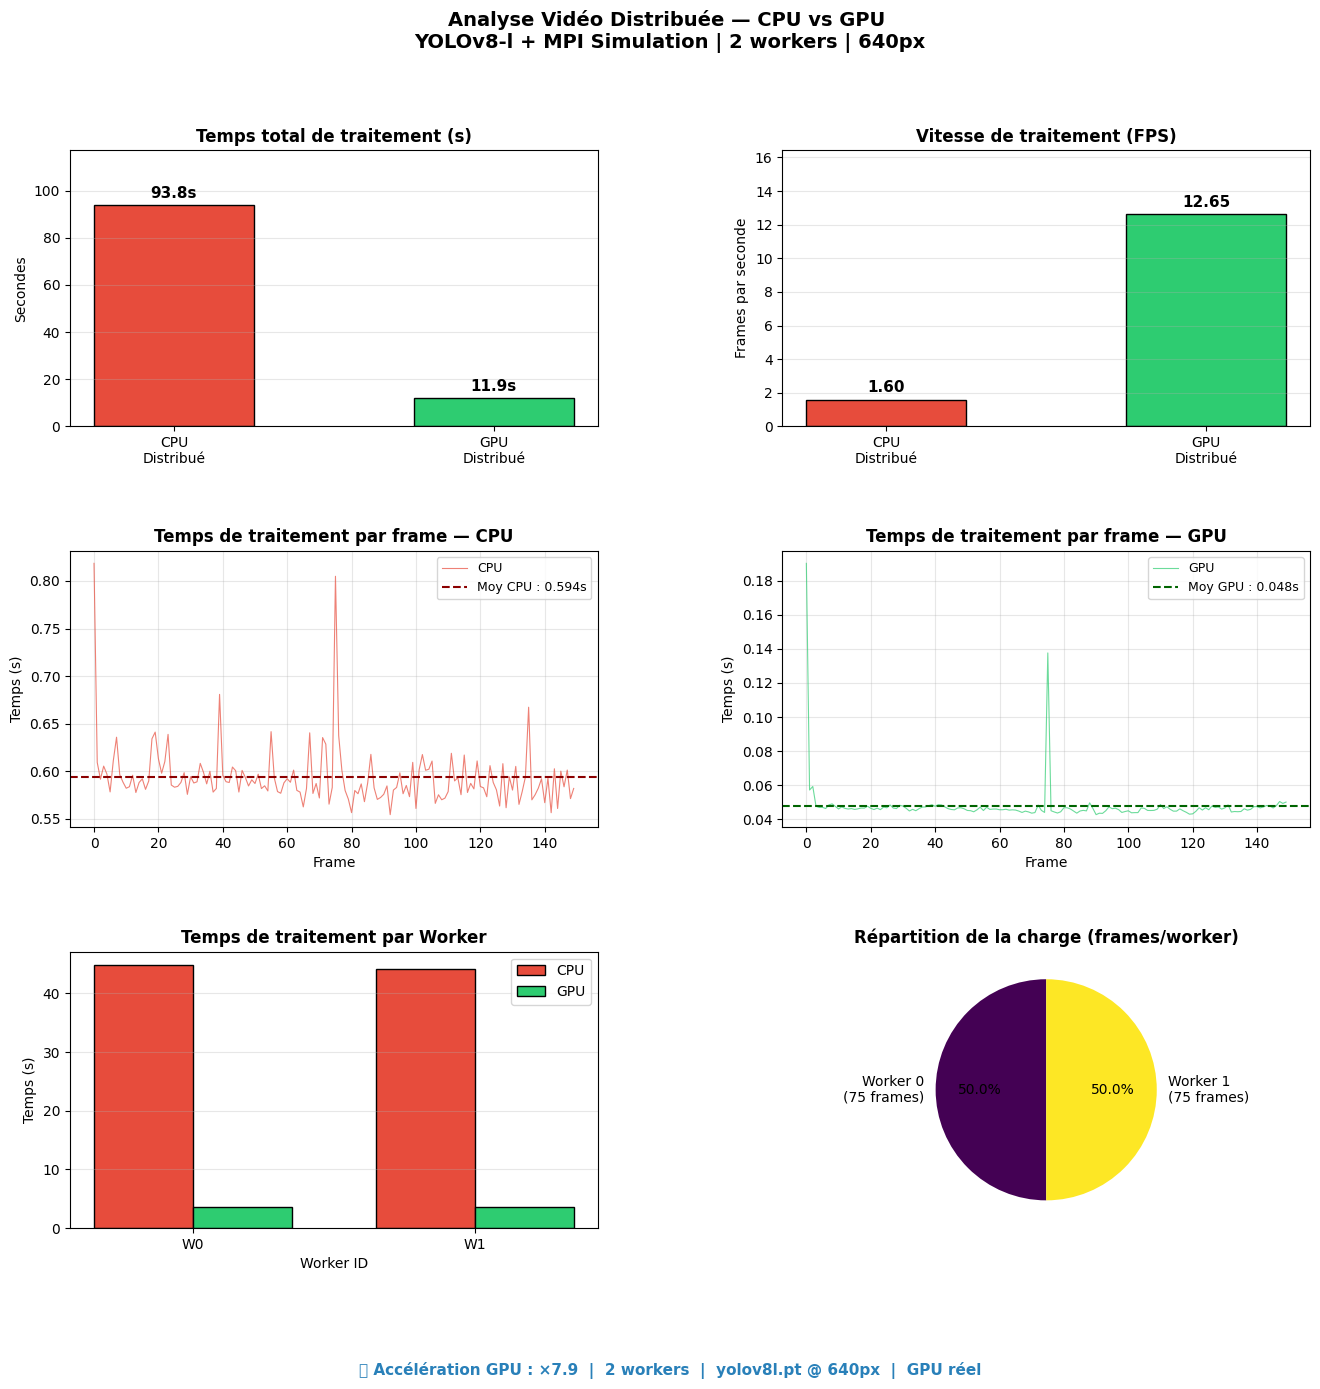


✅ Graphique sauvegardé : /kaggle/working/comparaison_cpu_gpu_distribue.png


In [23]:
print("═" * 60)
print("📊 GÉNÉRATION DES GRAPHIQUES COMPARATIFS")
print("═" * 60)

fig = plt.figure(figsize=(16, 14))
title_suffix = "(GPU simulé)" if not GPU_AVAILABLE else ""
fig.suptitle(
    f"Analyse Vidéo Distribuée — CPU vs GPU {title_suffix}\n"
    f"YOLOv8-{MODEL_NAME.replace('yolov8','').replace('.pt','')} + MPI Simulation | "
    f"{N_WORKERS} workers | {IMG_SIZE}px",
    fontsize=14, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ═══ 1. TEMPS TOTAL ═══
ax1 = fig.add_subplot(gs[0, 0])
vals_time = [cpu_results['total_time'], gpu_results['total_time']]
bars1 = ax1.bar(["CPU\nDistribué", "GPU\nDistribué"], vals_time,
                color=["#e74c3c", "#2ecc71"], width=0.5, edgecolor='black')
ax1.set_title("Temps total de traitement (s)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Secondes")
for bar, val in zip(bars1, vals_time):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals_time)*0.02,
             f"{val:.1f}s", ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_ylim(0, max(vals_time) * 1.25)
ax1.grid(axis='y', alpha=0.3)

# ═══ 2. FPS ═══
ax2 = fig.add_subplot(gs[0, 1])
vals_fps = [cpu_results['fps'], gpu_results['fps']]
bars2 = ax2.bar(["CPU\nDistribué", "GPU\nDistribué"], vals_fps,
                color=["#e74c3c", "#2ecc71"], width=0.5, edgecolor='black')
ax2.set_title("Vitesse de traitement (FPS)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Frames par seconde")
for bar, val in zip(bars2, vals_fps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals_fps)*0.02,
             f"{val:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_ylim(0, max(vals_fps) * 1.3)
ax2.grid(axis='y', alpha=0.3)

# ═══ 3. TEMPS PAR FRAME (distribution) ═══
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(cpu_results['times'], color="#e74c3c", linewidth=0.8, alpha=0.7, label="CPU")
ax3.axhline(np.mean(cpu_results['times']), color='darkred', linestyle='--', linewidth=1.5,
            label=f"Moy CPU : {np.mean(cpu_results['times']):.3f}s")
ax3.set_title("Temps de traitement par frame — CPU", fontsize=12, fontweight='bold')
ax3.set_xlabel("Frame")
ax3.set_ylabel("Temps (s)")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ═══ 4. TEMPS PAR FRAME GPU ═══
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(gpu_results['times'], color="#2ecc71", linewidth=0.8, alpha=0.7, label="GPU")
ax4.axhline(np.mean(gpu_results['times']), color='darkgreen', linestyle='--', linewidth=1.5,
            label=f"Moy GPU : {np.mean(gpu_results['times']):.3f}s")
ax4.set_title("Temps de traitement par frame — GPU", fontsize=12, fontweight='bold')
ax4.set_xlabel("Frame")
ax4.set_ylabel("Temps (s)")
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# ═══ 5. TEMPS PAR WORKER ═══
ax5 = fig.add_subplot(gs[2, 0])
worker_times_cpu = [sum(times) for _, _, times, _, _ in cpu_results['worker_results']]
worker_times_gpu = [sum(times) for _, _, times, _, _ in gpu_results['worker_results']]
x = np.arange(N_WORKERS)
w = 0.35
ax5.bar(x - w/2, worker_times_cpu, w, label='CPU', color='#e74c3c', edgecolor='black')
ax5.bar(x + w/2, worker_times_gpu, w, label='GPU', color='#2ecc71', edgecolor='black')
ax5.set_title("Temps de traitement par Worker", fontsize=12, fontweight='bold')
ax5.set_xlabel("Worker ID")
ax5.set_ylabel("Temps (s)")
ax5.set_xticks(x)
ax5.set_xticklabels([f"W{i}" for i in range(N_WORKERS)])
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# ═══ 6. RÉPARTITION DES FRAMES PAR WORKER ═══
ax6 = fig.add_subplot(gs[2, 1])
worker_frames = [e - s for s, e in chunks]
colors = plt.cm.viridis(np.linspace(0, 1, N_WORKERS))
ax6.pie(worker_frames,
        labels=[f"Worker {i}\n({worker_frames[i]} frames)" for i in range(N_WORKERS)],
        autopct='%1.1f%%', colors=colors, startangle=90)
ax6.set_title("Répartition de la charge (frames/worker)", fontsize=12, fontweight='bold')

# Accélération
speedup = cpu_results['total_time'] / gpu_results['total_time']
fig.text(0.5, 0.005,
         f"🚀 Accélération GPU : ×{speedup:.1f}  |  "
         f"{N_WORKERS} workers  |  {MODEL_NAME} @ {IMG_SIZE}px  |  "
         f"{'GPU réel' if GPU_AVAILABLE else 'GPU simulé'}",
         ha='center', fontsize=11, color='#2980b9', fontweight='bold')

graph_path = os.path.join(OUTPUT_DIR, "comparaison_cpu_gpu_distribue.png")
plt.savefig(graph_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : {graph_path}")

## 📋 Cellule 11 — Tableau récapitulatif des résultats

In [25]:
speedup = cpu_results['total_time'] / gpu_results['total_time']
n_cpu   = len(cpu_results['paths'])
n_gpu   = len(gpu_results['paths'])

print("\n" + "═" * 70)
print("📋 TABLEAU RÉCAPITULATIF — ANALYSE VIDÉO DISTRIBUÉE")
print("═" * 70)
print(f"""
  MÉTRIQUE                  CPU DISTRIBUÉ        GPU DISTRIBUÉ
  ─────────────────────────────────────────────────────────────
  Modèle YOLO             {MODEL_NAME:<21}{MODEL_NAME}
  Workers (nœuds)         {N_WORKERS:<21}{N_WORKERS}
  Résolution              {IMG_SIZE}px{'':<17}{IMG_SIZE}px
  Frames traitées         {n_cpu:<21}{n_gpu}
  Temps total             {cpu_results['total_time']:.2f}s{'':<18}{gpu_results['total_time']:.2f}s
  FPS traitement          {cpu_results['fps']:.2f}{'':<19}{gpu_results['fps']:.2f}
  Temps/frame moyen       {np.mean(cpu_results['times']):.3f}s{'':<17}{np.mean(gpu_results['times']):.3f}s
  CPU moyen (hôte)        {cpu_results['avg_cpu']:.1f}%{'':<18}{gpu_results['avg_cpu']:.1f}%
  Accélération GPU        —                    ×{speedup:.1f}
  ─────────────────────────────────────────────────────────────
""")

print("═" * 70)
print("📁 FICHIERS GÉNÉRÉS (dans /kaggle/working/)")
print("═" * 70)
output_files = [
    ("output_cpu_distribue.mp4",         "Vidéo annotée — mode CPU"),
    ("output_gpu_distribue.mp4",         "Vidéo annotée — mode GPU"),
    ("comparaison_cpu_gpu_distribue.png", "Graphiques comparatifs"),
]
for fname, desc in output_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"   ✅ {fname:<40} {size_mb:.1f} MB — {desc}")
    else:
        print(f"   ⚠️  {fname:<40} Non généré")

print("═" * 70)
print("✅ Analyse vidéo distribuée terminée avec succès")
print("   → Les fichiers sont téléchargeables depuis l'onglet Output (▶ Output)")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
📋 TABLEAU RÉCAPITULATIF — ANALYSE VIDÉO DISTRIBUÉE
══════════════════════════════════════════════════════════════════════

  MÉTRIQUE                  CPU DISTRIBUÉ        GPU DISTRIBUÉ
  ─────────────────────────────────────────────────────────────
  Modèle YOLO             yolov8l.pt           yolov8l.pt
  Workers (nœuds)         2                    2
  Résolution              640px                 640px
  Frames traitées         150                  150
  Temps total             93.75s                  11.86s
  FPS traitement          1.60                   12.65
  Temps/frame moyen       0.594s                 0.048s
  CPU moyen (hôte)        162.9%                  129.6%
  Accélération GPU        —                    ×7.9
  ─────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════════════
📁 FICHIERS GÉNÉRÉS (dans /kaggle/working/)
══════════

## 📝 Conclusion

### Architecture implémentée

| Étape | Implémentation | Concept MPI |
|-------|---------------|-------------|
| Découpage | `analyze_and_split_video()` → indices | `MPI_Scatter` |
| Lecture | Chaque worker lit son chunk depuis le fichier | Accès local aux données |
| Traitement | `Pool.map(process_worker)` (CPU) / séquentiel (GPU) | Parallélisme inter-rank |
| Sauvegarde | Frames JPEG sur disque au fil du traitement | Sortie locale par rank |
| Agrégation | `assemble_video_from_frames()` | `MPI_Gather` + reconstruction |

### Corrections appliquées pour Kaggle

| Problème original (Colab) | Solution appliquée |
|---|---|
| Toutes les frames en RAM | Streaming : chaque worker lit sa portion |
| YOLOv8-Large × 4 workers | YOLOv8-Nano, 2 workers |
| IMG_SIZE = 1280 | IMG_SIZE = 640 |
| Frames annotées accumulées en RAM | Sauvegarde JPEG immédiate sur disque |
| `Pool` sur GPU (conflit CUDA) | Séquentiel pour GPU, `Pool` pour CPU |

### Sur un vrai cluster HPC
```bash
# Remplacement de Pool par mpi4py :
mpirun -np 4 python script_mpi.py --video test.mp4 --device cuda
```

Chaque `rank` MPI remplacerait un worker, avec `comm.send()` / `comm.recv()` pour la coordination.
